# Unconstrained optimization - EGO


In [1]:
import numpy as np
from matplotlib import pyplot as plt

from smt_optim.benchmarks.registry import get_problem

from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtAutoModel

from smt_optim.acquisition_strategies import MFSEGO

## Unconstrained 1D optimization

This example will use the Sasena test function (2002). The bounds are $[0, 10]$

In [2]:
def sasena_2002(x: np.ndarray):
    return -np.sin(x) - np.exp(x / 100) + 10

bounds = np.array([[0, 10]])


In [3]:

obj_config = ObjectiveConfig(
    objective=[sasena_2002],
    type="minimize",
    surrogate=SmtAutoModel,           # set which GP to model the objective
)

prob_definition = Problem(
    obj_configs=[obj_config],
    design_space=bounds,
)

Once the problem is initialized, we can configure the optimization driver. We can set the configuration using the `DriverConfig` dataclass and then initialize the driver with the `Driver` class.

In our example, we set the following parameters:
- `max_iter` corresponds to the maximum number of iteration that will be performed.
- `nt_init` corresponds to the number of samples in the initial DOE. The initial DOE will be generated using LHS.
- `verbose` can be set to `True` or `False`. If set to `True` some basic information will be printed at the end of each iteration.
- `seed` allows to reproduce optimization run.

The `MFSEGO` optimization strategy must be pass to perform `EGO` (unconstrained optimization), `SEGO` (constrained optimization) and `MFSEGO` (unconstrained or constrained and multi-fidelity optimization).


In [4]:
driver_config = DriverConfig(
    max_iter = 5,              # stopping criterion
    nt_init = 2,                # number of sample in the initial DoE
    verbose = True,
    seed=42,
)

# configure the optimizer. Note: if a single fidelity level is given to the MFSEGO acquisition strategy, it falls back to the SEGO framework.
driver = Driver(prob_definition, driver_config, MFSEGO)

We can launch the optimization using the `optimize()` class method. It will return a `State` object.

In [5]:
# return the optimization data
state = driver.optimize()

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1              3    8.13516e+00      0.000e+00              1          0.039          0.060
             2              4    8.11303e+00      0.000e+00              1          0.115          0.056
             3              5    8.03885e+00      0.000e+00              1          0.104          0.056
             4              6    7.91831e+00      0.000e+00              1          0.093          0.045
             5              7    7.91826e+00      0.000e+00              1          0.099          0.053


Once the optimization terminated, we can recover the best sample using the `get_best_sample()` class method. It will return a `Sample` dataclass with the lowest objective value.


In [6]:
sample = state.get_best_sample()
sample

======= sample data =======
x =             [7.85760084]
obj =           [7.91826098]
cstr =          []
eval_time =     [6.07000038e-06]
------- meta data -------
iter =     5
budget =     7
fidelity =     0
rscv =     0.0

We can only also recover the entire DOE using the `dataset` attribute.

In [7]:
dataset = state.dataset

data = dataset.export_as_dict()
xt = data["x"]
yt = data["obj"]


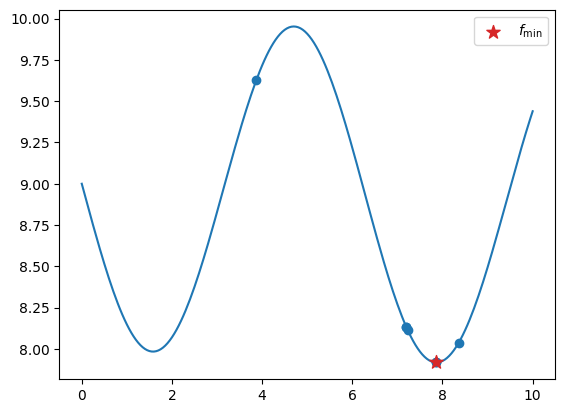

In [8]:
x_test = np.linspace(0, 10, 201)
y_test = sasena_2002(x_test)

fig, ax = plt.subplots()
ax.plot(x_test, y_test)
ax.scatter(xt, yt)
ax.scatter(sample.x, sample.obj, 100, marker="*", color="C3", zorder=20, label=r"$f_\min$")

ax.legend()
plt.show()


## Unconstrained 2D optimization

In [9]:
def modified_branin(x):
    """
    Engineering Design via Surrogate Modelling: A Practical Guide
    A. I. J. Forrester, A. Sóbester and A. J. Keane
    2008
    """
    X1 = 15 * x[0] - 5
    X2 = 15 * x[1]

    a = 1
    b = 5.1 / (4 * np.pi ** 2)
    c = 5 / np.pi
    d = 6
    e = 10
    ff = 1 / (8 * np.pi)
    f = (a * (X2 - b * X1 ** 2 + c * X1 - d) ** 2 + e * (1 - ff) * np.cos(X1) + e) + 5 * x[0]

    return f


bounds = np.array([
    [0, 1],
    [0, 1],
])

In [10]:
obj_config = ObjectiveConfig(
    [modified_branin],
    type="minimize",
    surrogate=SmtAutoModel,
)

prob_definition = Problem(
    obj_configs=[obj_config],
    design_space=bounds,            # problem bounds
)

opt_config = DriverConfig(
    max_iter = 20,
    nt_init = 3,
    verbose = True,
    scaling = True,
    seed=42,
)

driver = Driver(prob_definition, opt_config, MFSEGO)

state = driver.optimize()

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1              4    1.56584e+01      0.000e+00              1          0.172          0.272
             2              5    1.56584e+01      0.000e+00              1          0.288          0.252
             3              6    1.56584e+01      0.000e+00              1          0.287          0.348
             4              7    1.14165e+01      0.000e+00              1          0.319          0.258
             5              8    1.08062e+01      0.000e+00              1          0.316          0.367
             6              9    6.27138e+00      0.000e+00              1          0.268          0.345
             7             10    4.43145e+00      0.000e+00              1          0.271          0.403
             8             11    4.43145e+00      0.000e+00              1          0.329          0.499
             9             12    4.43145e+00      0.000

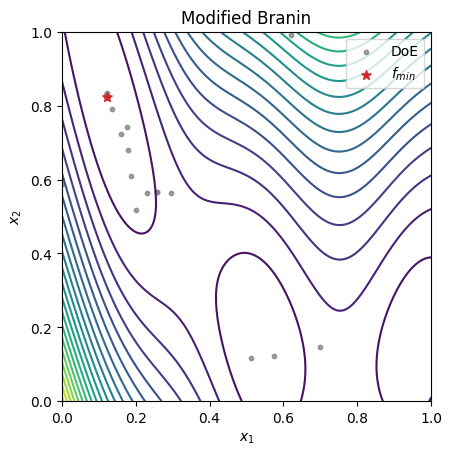

In [11]:
# get the best sample in the dataset
sample = state.get_best_sample()
xt = state.dataset.export_as_dict()["x"]

X = np.linspace(bounds[0, 0], bounds[0, 1], 201)
Y = np.linspace(bounds[1, 0], bounds[1, 1], 201)
XX, YY = np.meshgrid(X, Y)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])

for i in range(data.shape[0]):
    z[i] = modified_branin(data[i, :])

Z = z.reshape(XX.shape)

fig, ax = plt.subplots()

ax.set_title("Modified Branin")

# plot the test function
ax.contour(XX, YY, Z, levels=20)

# plot the points in the final DoE
ax.scatter(xt[:, 0], xt[:, 1], 10, color="C7", alpha=0.75, label="DoE")

# plot the best sample in the final DoE
ax.scatter(sample.x[0], sample.x[1], 50, c="C3", marker="*", label=r"$f_{min}$", zorder=30)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")

ax.legend()
ax.set_aspect("equal")
plt.show()